In [76]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import numpy as np
from scipy.ndimage import gaussian_filter1d
import cv2
import matplotlib.pyplot as plt

In [77]:
MAX_CELLS = 150

TARGET_SIGMA = 0.85

MODEL_PATH = "cell_counter_resnet_new.pth"

In [78]:
def get_target_distribution(count, max_cells, sigma):
    target = np.zeros(max_cells + 1)
    if count <= max_cells:
        target[int(count)] = 1.0
        target = gaussian_filter1d(target, sigma=sigma, mode="constant")
        target = target / target.max()

    return target.astype(np.float32)

In [79]:
d = get_target_distribution(2, 9, TARGET_SIGMA)
d, d.sum()

(array([0.06277703, 0.50055313, 1.        , 0.50055313, 0.06277703,
        0.00197266, 0.        , 0.        , 0.        , 0.        ],
       dtype=float32),
 np.float32(2.128633))

In [80]:
d = get_target_distribution(0, 9, TARGET_SIGMA)
d, d.sum()

(array([1.        , 0.50055313, 0.06277703, 0.00197266, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       dtype=float32),
 np.float32(1.5653028))

In [81]:
d = get_target_distribution(12, 9, TARGET_SIGMA)
d, d.sum()

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 np.float32(0.0))

In [82]:
import os
os.chdir('/mnt/d/code/notebooks/2d_graphics/')

In [83]:
import numpy as np
import random

from BloodCellDataset import slice_dataset, BloodCellDataset, PATCH_SIZE

np.random.seed(0)
random.seed(0)

bg_patches, cell_data, bg_masks = slice_dataset(
    train_dir="train",
    sample_size=100,
    patch_size=PATCH_SIZE,
)
n = 256
# n = 1280
dataset = BloodCellDataset(
    patch_size=PATCH_SIZE,
    img_size=(PATCH_SIZE * 9, PATCH_SIZE * 12),  # orig size
    # img_size=(PATCH_SIZE * 4, PATCH_SIZE * 5), # FIXME: cells are too big - fix paching/resizing logic
    n=n,
)
dataset.fit((bg_patches, bg_masks, cell_data))

Slicing dataset: 100%|████████████████████████████████████████████████████| 100/100 [00:16<00:00,  5.90it/s]


Extracted 8887 background patches and 6050 cells


In [84]:
gray_img = dataset[0][1]
gray_img

array([[220, 220, 220, ..., 225, 225, 225],
       [220, 220, 220, ..., 224, 224, 224],
       [222, 222, 222, ..., 222, 222, 221],
       ...,
       [226, 226, 226, ..., 222, 222, 222],
       [228, 228, 228, ..., 222, 222, 221],
       [229, 229, 228, ..., 222, 221, 221]],
      shape=(1152, 1536), dtype=uint8)

In [85]:
gray_img = torch.from_numpy(gray_img).float()
gray_img = gray_img / 255.0
gray_img, gray_img.shape

(tensor([[0.8627, 0.8627, 0.8627,  ..., 0.8824, 0.8824, 0.8824],
         [0.8627, 0.8627, 0.8627,  ..., 0.8784, 0.8784, 0.8784],
         [0.8706, 0.8706, 0.8706,  ..., 0.8706, 0.8706, 0.8667],
         ...,
         [0.8863, 0.8863, 0.8863,  ..., 0.8706, 0.8706, 0.8706],
         [0.8941, 0.8941, 0.8941,  ..., 0.8706, 0.8706, 0.8667],
         [0.8980, 0.8980, 0.8941,  ..., 0.8706, 0.8667, 0.8667]]),
 torch.Size([1152, 1536]))

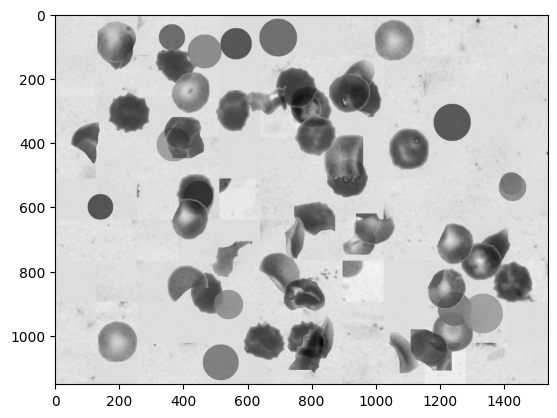

In [86]:
import matplotlib.pyplot as plt

plt.imshow(gray_img.cpu().numpy(), cmap="gray")

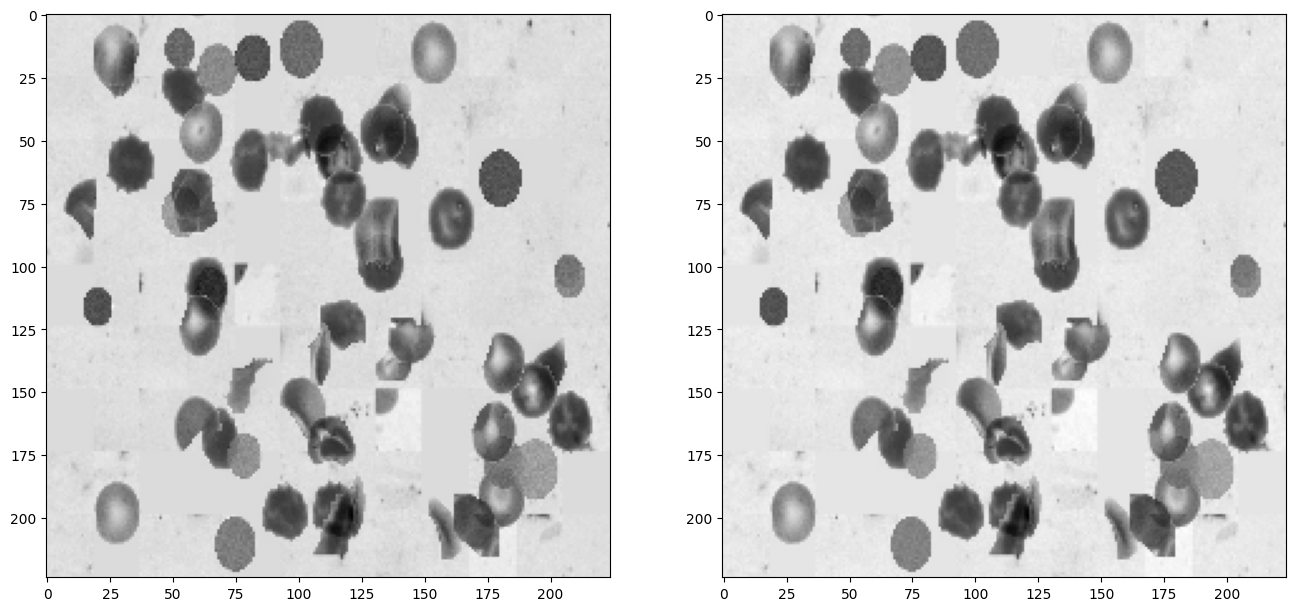

In [87]:
import cv2
image1 = cv2.resize(
    gray_img.cpu().numpy(), (224, 224), interpolation=cv2.INTER_LANCZOS4
)
image2 = cv2.resize(gray_img.cpu().numpy(), (224, 224), interpolation=cv2.INTER_LINEAR)
fig, axs = plt.subplots(1, 2, figsize=(16, 9))
axs[0].imshow(image1, cmap="gray")
axs[1].imshow(image2, cmap="gray")

In [88]:
gray_img = gray_img.unsqueeze(0)
gray_img.shape

torch.Size([1, 1152, 1536])

In [89]:
class BloodCellTorchDataset(Dataset):
    def __init__(self, base_dataset, max_cells, sigma):
        self.base_dataset = base_dataset
        self.max_cells = max_cells
        self.sigma = sigma
        # self.data = {}

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # if idx in self.data:
        #     return self.data[idx]
        
        _, gray_img, _, num_cells = self.base_dataset[idx]

        gray_img = cv2.resize(gray_img, (224, 224), interpolation=cv2.INTER_LINEAR)

        img_tensor = torch.from_numpy(gray_img).float()
        img_tensor = img_tensor / 255.0

        # ResNet: (C, H, W)
        img_tensor = img_tensor.unsqueeze(0)  # (H, W) -> (1, H, W)

        target_vec = get_target_distribution(num_cells, self.max_cells, self.sigma)
        target_tensor = torch.from_numpy(target_vec)

        return img_tensor, target_tensor
        # self.data[idx] = img_tensor, target_tensor
        # return self.data[idx]
    

In [90]:
torch_dataset = BloodCellTorchDataset(dataset, MAX_CELLS, TARGET_SIGMA)

In [91]:
train_set, val_set = torch.utils.data.random_split(
    torch_dataset, [0.8, 0.2]
)
len(train_set), len(val_set)

(205, 51)

In [92]:
B = 8  # on original
# B = 32  # on (224, 224)
train_loader = DataLoader(train_set, batch_size=B, shuffle=True, drop_last=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False, drop_last=True)

In [93]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [94]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [95]:
model.conv1

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

In [96]:
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(model.fc.in_features, MAX_CELLS + 1, bias=True)

In [97]:
model(gray_img.unsqueeze(0))

tensor([[ 0.0658,  0.1258, -0.0144,  0.6492,  0.5376, -0.4499,  0.2106,  0.0816,
         -0.0626, -1.0497,  0.6552,  0.2738, -0.2265,  0.4594, -0.0032, -0.1562,
         -0.8265, -0.4597, -0.2274,  0.0378, -0.1031,  0.3783,  0.9795,  0.0199,
         -0.2877, -0.4263, -0.2383, -1.3760, -0.0967, -0.3294, -0.3772,  0.7391,
         -0.3445,  1.1238,  0.0075,  0.0454,  0.5800,  0.1411,  0.6973,  0.7281,
         -0.3142, -0.1115,  0.2051, -0.7011, -0.4714, -1.5849,  0.3255,  0.0203,
         -0.5061, -0.2417, -0.0665, -0.7125, -0.2444,  0.3236, -0.8123, -0.8082,
          0.1073, -0.3199, -1.0652,  0.5534, -0.1414, -0.4854,  0.0194,  0.2912,
          1.1208,  0.2603,  0.2223, -0.0826,  0.0357, -0.0540, -0.0210, -0.1600,
         -0.4780,  0.3278,  0.2560, -0.6225,  0.5631, -0.1453,  0.5943, -0.5249,
         -0.2823, -0.0218, -0.8573, -0.5799,  0.1702,  0.2716, -0.0090, -0.4246,
          0.3415, -0.2606,  0.3758, -0.3195,  0.2862,  0.1840,  0.8493,  0.3352,
         -0.1833, -0.5960, -

In [98]:
class ResNetCounter(nn.Module):
    def __init__(self, num_classes):
        super(ResNetCounter, self).__init__()

        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.model.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes, bias=True)

        self.sigmoid = nn.Sigmoid()  # BCELoss

    def forward(self, x):
        x = self.model(x)
        x = self.sigmoid(x)
        return x

In [111]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetCounter(num_classes=MAX_CELLS + 1).to(device)

In [112]:
device

device(type='cuda')

In [113]:
model(gray_img.unsqueeze(0).to(device)).cpu()

tensor([[0.7323, 0.6533, 0.4907, 0.4077, 0.3466, 0.5843, 0.5490, 0.6575, 0.4184,
         0.5212, 0.6204, 0.5106, 0.5982, 0.3904, 0.4230, 0.7541, 0.6784, 0.3775,
         0.6455, 0.4059, 0.7761, 0.5020, 0.4498, 0.4879, 0.6267, 0.7152, 0.5749,
         0.3972, 0.5016, 0.7467, 0.6898, 0.4714, 0.6941, 0.4300, 0.4623, 0.4330,
         0.3062, 0.4320, 0.4741, 0.5300, 0.4251, 0.6078, 0.3534, 0.2820, 0.6208,
         0.3303, 0.4056, 0.5708, 0.5582, 0.5156, 0.3715, 0.4036, 0.4121, 0.5086,
         0.3260, 0.5143, 0.5079, 0.5211, 0.3042, 0.4758, 0.4419, 0.5786, 0.3631,
         0.3121, 0.6716, 0.7253, 0.6159, 0.5661, 0.5364, 0.4406, 0.5959, 0.2963,
         0.4819, 0.7442, 0.3705, 0.4726, 0.1899, 0.5375, 0.6303, 0.4643, 0.5583,
         0.6054, 0.4745, 0.3307, 0.5116, 0.5190, 0.4317, 0.6172, 0.4056, 0.6471,
         0.4536, 0.3824, 0.6691, 0.6275, 0.3684, 0.3683, 0.5514, 0.5808, 0.4764,
         0.6646, 0.4339, 0.5231, 0.6141, 0.6393, 0.5255, 0.3401, 0.4703, 0.4998,
         0.2724, 0.4850, 0.6

In [114]:
# lr = 1e-3

# criterion = torch.nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=lr)

lr = 1e-4

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [115]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

n_epochs = 10 # orig
# n_epochs = 30 # sized
for epoch in range(n_epochs):
    print(f"Epoch: {epoch+1}")
    train_epoch_losses = []
    train_epoch_accuracies = []
    for idx, (image, label) in enumerate(train_loader):
        image, label = image.to(device), label.to(device)

        model.train()
        optimizer.zero_grad()
        prediction = model(image)
        # loss = criterion(prediction.squeeze(), label.long().squeeze())
        loss = criterion(prediction, label)
        loss.backward()
        optimizer.step()
        loss = loss.item()

        train_epoch_losses.append(loss)
        # print(loss)

        if (idx + 1) %100 == 0: print(loss)

    train_epoch_loss = np.mean(train_epoch_losses)
    print(f"Train Loss: {train_epoch_loss:.4f}")
    train_losses.append(train_epoch_loss)

    # with torch.no_grad():
    #     for idx, (image, label) in enumerate(train_loader):
    #         image, label = image.to(device), label.to(device)

    #         model.eval()
    #         prediction = model(image)
    #         max_values, argmaxes = prediction.max(-1)
    #         is_correct = argmaxes == label.int().squeeze()
    #         is_correct = is_correct.cpu().numpy().tolist()
    #         train_epoch_accuracies.extend(is_correct)
    # train_epoch_accuracy = np.mean(train_epoch_accuracies)
    # print(f"Train Accuracy: {train_epoch_accuracy*100:.2f}%")
    # train_accuracies.append(train_epoch_accuracy)

    test_epoch_losses = []
    test_epoch_accuracies = []
    with torch.no_grad():
        for idx, (image, label) in enumerate(val_loader):
            image, label = image.to(device), label.to(device)

            # print(label)
            model.eval()
            prediction = model(image)
            # loss = criterion(prediction.squeeze(), label.long().squeeze())
            loss = criterion(prediction, label)
            loss = loss.item()
            test_epoch_losses.append(loss)

            model.eval()
            preds = torch.argmax(prediction, dim=1)
            true_vals = torch.argmax(label, dim=1)

            mae = torch.sum(torch.abs(preds - true_vals)).item()
            test_epoch_accuracies.append(mae)

    test_epoch_loss = np.mean(test_epoch_losses)
    test_epcoh_accuracy = np.mean(test_epoch_accuracies)
    print(f"Test Loss: {test_epoch_loss:.4f}, MAE: {test_epcoh_accuracy:.2f}")
    test_losses.append(test_epoch_loss)

Epoch: 1
Train Loss: 0.5150
Test Loss: 0.3615, MAE: 51.20
Epoch: 2
Train Loss: 0.2230
Test Loss: 0.1569, MAE: 43.59
Epoch: 3
Train Loss: 0.1216
Test Loss: 0.0985, MAE: 10.78
Epoch: 4
Train Loss: 0.0888
Test Loss: 0.0813, MAE: 6.51
Epoch: 5
Train Loss: 0.0745
Test Loss: 0.0722, MAE: 6.22
Epoch: 6
Train Loss: 0.0668
Test Loss: 0.0687, MAE: 6.08
Epoch: 7
Train Loss: 0.0612
Test Loss: 0.0659, MAE: 6.53
Epoch: 8
Train Loss: 0.0570
Test Loss: 0.0647, MAE: 6.59
Epoch: 9
Train Loss: 0.0517
Test Loss: 0.0641, MAE: 6.65
Epoch: 10
Train Loss: 0.0475
Test Loss: 0.0636, MAE: 6.18


In [116]:
# import gc; gc.collect()
# torch.cuda.empty_cache()

In [117]:
model = ResNetCounter(num_classes=MAX_CELLS + 1).to(device)


criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [118]:
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        loss = loss.item()
        # print(loss)
        # if (i + 1) %100 == 0: print(loss)

        running_loss += loss

    model.eval()
    val_loss = 0.0
    mae = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            true_vals = torch.argmax(targets, dim=1)

            mae += torch.sum(torch.abs(preds - true_vals)).item()

    epoch_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)

    mean_mae = mae / len(val_set)

    print(
        f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | MAE: {mean_mae:.2f}"
    )

Epoch 1/10 | Train Loss: 0.4986 | Val Loss: 0.3679 | MAE: 28.53
Epoch 2/10 | Train Loss: 0.2161 | Val Loss: 0.1810 | MAE: 42.06
Epoch 3/10 | Train Loss: 0.1196 | Val Loss: 0.0964 | MAE: 15.45
Epoch 4/10 | Train Loss: 0.0879 | Val Loss: 0.0799 | MAE: 6.33
Epoch 5/10 | Train Loss: 0.0742 | Val Loss: 0.0721 | MAE: 6.84
Epoch 6/10 | Train Loss: 0.0662 | Val Loss: 0.0678 | MAE: 6.33
Epoch 7/10 | Train Loss: 0.0611 | Val Loss: 0.0669 | MAE: 6.63
Epoch 8/10 | Train Loss: 0.0556 | Val Loss: 0.0639 | MAE: 6.04
Epoch 9/10 | Train Loss: 0.0510 | Val Loss: 0.0636 | MAE: 6.80
Epoch 10/10 | Train Loss: 0.0467 | Val Loss: 0.0626 | MAE: 6.45


In [119]:
# import gc; gc.collect()
# torch.cuda.empty_cache()

In [129]:
img, tgt = list(iter(val_loader))[0]

In [131]:
img.shape

torch.Size([1, 1, 224, 224])

In [134]:
model.eval()
with torch.no_grad():
    pred_vector = model(img.to(device)).cpu()

    pred_count = torch.argmax(pred_vector).item()
    true_count = torch.argmax(tgt).item()

pred_count, true_count

(63, 56)

In [120]:
# model_dir = "./models/"
# os.makedirs(model_dir, exist_ok=True)

# model_path = os.path.join(model_dir, 'best_model.pth')
# torch.save(model.state_dict(), model_path)

In [121]:
# model = ResNetCounter(num_classes=MAX_CELLS + 1).to(device)

# model.load_state_dict(torch.load(model_path, weights_only=True)) # example
# model.load_state_dict(torch.load(model_path, map_location=device))
# model.eval()